## Introducción

En estos ejercicios vamos a trabajar con  datasets que representan el conjunto de personajes de Marvel en sus cómics con características de cada uno de ellos.

Las columnas del dataframe significan lo siguiente:

1. `page_id`: Identificador único de la página del personaje dentro de la wikia.
2. `name`: Nombre del personaje.
3. `urlslug`: URL única dentro de la wikia que lleva a la página del personaje.
4. `ID`: Estado de identidad del personaje (Identidad secreta, pública, o sin identidad dual en Marvel).
5. `ALIGN`: Alineación del personaje (Bueno, Malo o Neutral).
6. `EYE`: Color de ojos del personaje.
7. `HAIR`: Color de cabello del personaje.
8. `SEX`: Sexo del personaje (e.g. Masculino, Femenino, etc.).
9. `GSM`: Indica si el personaje pertenece a una minoría de género o sexual (e.g. Homosexual, Bisexual).
10. `ALIVE`: Indica si el personaje está vivo o fallecido.
11. `APPEARANCES`: Número de apariciones del personaje en cómics (al 2 de septiembre de 2014; el número puede estar desactualizado).
12. `FIRST APPEARANCE`: Mes y año de la primera aparición del personaje en un cómic, si está disponible.
13. `YEAR`: Año de la primera aparición del personaje en un cómic, si está disponible.



# Parte 1: Extracción de Datos

Concatena todas las fuentes en un solo Dataset , añade para cada fuente una columna , que indique el origen, a fin de que cuando se concatenen poder tener trazabilidad sobre el origen de donde vino el dato. Para MongoDB usa Mongo Compass


In [2]:
import pandas as pd
import sqlite3
from pymongo import MongoClient
import pyodbc

df_api = pd.read_json('./fuentes marvel/marvel_api_response.json')
df_api['origen'] = 'API_JSON'

df_txt = pd.read_csv('./fuentes marvel/marvel_characters.txt', sep=';')
df_txt['origen'] = 'TXT'

df_excel = pd.read_excel('./fuentes marvel/marvel_characters.xlsx')
df_excel['origen'] = 'EXCEL'

client = MongoClient('mongodb://localhost:27017/')
db = client['MarvelDB']
coleccion = db['personajes']

datos_mongo = list(coleccion.find())
df_mongo = pd.DataFrame(datos_mongo)

if '_id' in df_mongo.columns:
    df_mongo = df_mongo.drop(columns=['_id'])

df_mongo['origen'] = 'MONGODB'

conexion_sqlite = sqlite3.connect('./fuentes marvel/marvel_sqlite.db')

df_sqlite = pd.read_sql('SELECT * FROM marvel_characters', conexion_sqlite)
df_sqlite['origen'] = 'SQLITE'

conexion_sqlserver = pyodbc.connect(
    'DRIVER={ODBC Driver 17 for SQL Server};'
    'SERVER=DESKTOP-R850GIB;'
    'DATABASE=MarvelDB;'
    'Trusted_Connection=yes;'
)

df_sqlserver = pd.read_sql('SELECT * FROM marvel_characters', conexion_sqlserver)
df_sqlserver['origen'] = 'SQLSERVER'

df_final = pd.concat([
    df_api,
    df_txt,
    df_excel,
    df_mongo,
    df_sqlite,
    df_sqlserver
], ignore_index=True)

display(df_final.shape)
df_final.head(5)

C:\Users\User\AppData\Local\Temp\ipykernel_7260\1078952945.py:39: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_sqlserver = pd.read_sql('SELECT * FROM marvel_characters', conexion_sqlserver)


(81880, 30)

,status,code,message,total_records,data,origen,ID,Name,URL,Identity,...,name,urlslug,ALIGN,EYE,HAIR,SEX,ALIVE,APPEARANCES,FIRST APPEARANCE,FIRST_APPEARANCE
0,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 1678, 'name': 'Spider-Man (Peter P...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 7139, 'name': 'Captain America (St...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 64786, 'name': 'Wolverine (James \...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 1868, 'name': 'Iron Man (Anthony \...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 2460, 'name': 'Thor (Thor Odinson)...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Parte 2: Análisis Exploratorio y Limpieza de Datos

En esta sección el estudiante debe realizar el análisis exploratorio de datos (EDA), se detectarán outliers, se limpiará el dataset y se responderán preguntas sobre los datos.


## 2.1 EDA Inicial

Se realiza un análisis exploratorio inicial del dataset para comprender su estructura, tipos de datos, cantidad de valores nulos y estadísticas descriptivas básicas.


In [3]:
df_final.info()
display(df_final.shape)
display(df_final.head(5))
display(df_final.tail(5))
display(df_final.isnull().sum().sort_values(ascending=False))
display(df_final.astype(str).duplicated().sum())
display(df_final.dtypes)
display(df_final.astype(str).nunique().sort_values(ascending=False))

<class 'pandas.DataFrame'>
RangeIndex: 81880 entries, 0 to 81879
Data columns (total 30 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status            16376 non-null  str    
 1   code              16376 non-null  float64
 2   message           16376 non-null  str    
 3   total_records     16376 non-null  float64
 4   data              16376 non-null  object 
 5   origen            81880 non-null  str    
 6   ID                61734 non-null  object 
 7   Name              16376 non-null  str    
 8   URL               16376 non-null  str    
 9   Identity          12606 non-null  str    
 10  Alignment         13564 non-null  str    
 11  Eyes              6609 non-null   str    
 12  Hair              12112 non-null  str    
 13  Sex               15522 non-null  str    
 14  GSM               32932 non-null  str    
 15  Status            16373 non-null  str    
 16  Appearances       15280 non-null  float64
 17  Firs

(81880, 30)

,status,code,message,total_records,data,origen,ID,Name,URL,Identity,...,name,urlslug,ALIGN,EYE,HAIR,SEX,ALIVE,APPEARANCES,FIRST APPEARANCE,FIRST_APPEARANCE
0,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 1678, 'name': 'Spider-Man (Peter P...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 7139, 'name': 'Captain America (St...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 64786, 'name': 'Wolverine (James \...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 1868, 'name': 'Iron Man (Anthony \...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,success,200.0,Marvel characters retrieved successfully,16376.0,"{'page_id': 2460, 'name': 'Thor (Thor Odinson)...",API_JSON,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,status,code,message,total_records,data,origen,ID,Name,URL,Identity,...,name,urlslug,ALIGN,EYE,HAIR,SEX,ALIVE,APPEARANCES,FIRST APPEARANCE,FIRST_APPEARANCE
81875,NaN,NaN,NaN,NaN,NaN,SQLSERVER,Secret Identity,NaN,NaN,NaN,...,Thor (Taskmaster Robot) (Earth-616),\/Thor_(Taskmaster_Robot)_(Earth-616),Bad Characters,NULL,Blond Hair,Male Characters,Living Characters,1.0,NaN,Oct-98
81876,NaN,NaN,NaN,NaN,NaN,SQLSERVER,Secret Identity,NaN,NaN,NaN,...,Iron Man (Taskmaster Robot) (Earth-616),\/Iron_Man_(Taskmaster_Robot)_(Earth-616),Bad Characters,NULL,NULL,Agender Characters,Living Characters,1.0,NaN,Oct-98
81877,NaN,NaN,NaN,NaN,NaN,SQLSERVER,Secret Identity,NaN,NaN,NaN,...,Captain America (Taskmaster Robot) (Earth-616),\/Captain_America_(Taskmaster_Robot)_(Earth-616),Bad Characters,NULL,NULL,Male Characters,Living Characters,1.0,NaN,Oct-98
81878,NaN,NaN,NaN,NaN,NaN,SQLSERVER,Secret Identity,NaN,NaN,NaN,...,Sub-Mariner (Taskmaster Robot) (Earth-616),\/Sub-Mariner_(Taskmaster_Robot)_(Earth-616),Bad Characters,NULL,NULL,Male Characters,Living Characters,1.0,NaN,Oct-98
81879,NaN,NaN,NaN,NaN,NaN,SQLSERVER,Secret Identity,NaN,NaN,NaN,...,Hulk (Taskmaster Robot) (Earth-616),\/Hulk_(Taskmaster_Robot)_(Earth-616),Bad Characters,NULL,NULL,Male Characters,Living Characters,1.0,NaN,Oct-98


First_Appearance    81880
Eyes                75271
Hair                69768
Identity            69274
Alignment           68316
Appearances         66600
Sex                 66358
Status              65507
code                65504
message             65504
URL                 65504
data                65504
total_records       65504
status              65504
Name                65504
FIRST_APPEARANCE    65504
FIRST APPEARANCE    49943
GSM                 48948
EYE                 42519
HAIR                37016
ALIGN               35564
APPEARANCES         34944
SEX                 33606
ALIVE               32755
name                32752
urlslug             32752
page_id             32752
ID                  20146
Year                18821
origen                  0
dtype: int64

np.int64(0)

status                  str
code                float64
message                 str
total_records       float64
data                 object
origen                  str
ID                   object
Name                    str
URL                     str
Identity                str
Alignment               str
Eyes                    str
Hair                    str
Sex                     str
GSM                     str
Status                  str
Appearances         float64
First_Appearance    float64
Year                 object
page_id             float64
name                    str
urlslug                 str
ALIGN                   str
EYE                     str
HAIR                    str
SEX                     str
ALIVE                   str
APPEARANCES          object
FIRST APPEARANCE        str
FIRST_APPEARANCE        str
dtype: object

ID                  16382
data                16376
Name                16376
URL                 16376
urlslug             16376
name                16376
page_id             16376
FIRST APPEARANCE      833
FIRST_APPEARANCE      833
APPEARANCES           359
Appearances           358
Year                   76
HAIR                   27
EYE                    26
Hair                   25
Eyes                   24
GSM                     8
SEX                     6
ALIGN                   5
origen                  5
Identity                4
Sex                     4
ALIVE                   4
Alignment               3
Status                  2
message                 1
code                    1
status                  1
total_records           1
First_Appearance        0
dtype: int64

### Gráfico 1: Distribución por Alineación (ALIGN)

Visualiza cuántos personajes hay de cada tipo de alineación (Bueno, Malo, Neutral, etc.).


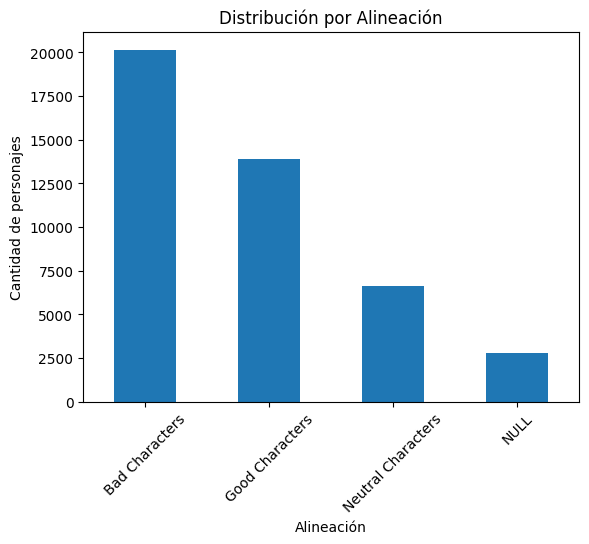

In [4]:
import matplotlib.pyplot as plt

df_final['ALIGN'] = df_final['ALIGN'].replace(['', ' '], pd.NA)

df_final['ALIGN'].value_counts().plot(kind='bar')

plt.title('Distribución por Alineación')
plt.xlabel('Alineación')
plt.ylabel('Cantidad de personajes')

plt.xticks(rotation=45)

plt.show()

## 2.2 Cálculo de Outliers




In [5]:
df_final['APPEARANCES'] = pd.to_numeric(df_final['APPEARANCES'], errors='coerce')

columnas_numericas = ['APPEARANCES']

resumen_outliers = []

for col in columnas_numericas:
    q1 = df_final[col].quantile(0.25)

    q3 = df_final[col].quantile(0.75)

    iqr = q3 - q1

    limite_inferior = max(0, q1 - 1.5 * iqr)
    limite_superior = q3 + 1.5 * iqr

    outliers = df_final[
        (df_final[col] < limite_inferior) |
        (df_final[col] > limite_superior)
    ]

    resumen_outliers.append({
        'columna': col,
        'Q1': q1,
        'Q3': q3,
        'IQR': iqr,
        'limite_inferior': limite_inferior,
        'limite_superior': limite_superior,
        'cantidad_outliers': outliers.shape[0]
    })

display(
    pd.DataFrame(resumen_outliers)
    .sort_values('cantidad_outliers', ascending=False)
)

,columna,Q1,Q3,IQR,limite_inferior,limite_superior,cantidad_outliers
0,APPEARANCES,1.0,8.0,7.0,0,18.5,5814


### Gráfico 3: Diagrama BoxPlot 

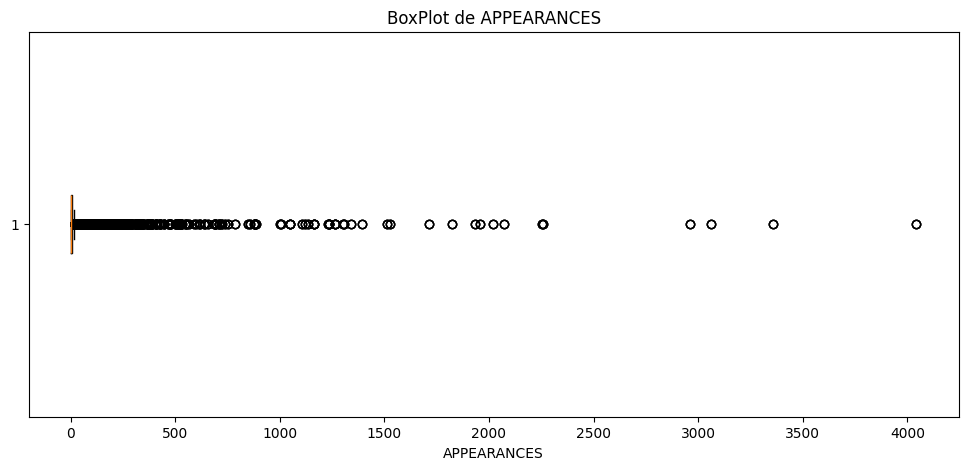

In [6]:
for col in columnas_numericas:
    plt.figure(figsize=(12,5))
    plt.boxplot(df_final[col].dropna(), vert=False)
    plt.title(f'BoxPlot de {col}')
    plt.xlabel(col)
    plt.show()

### Gráfico 4: Diagrama de densidad de núcleo (KDE)

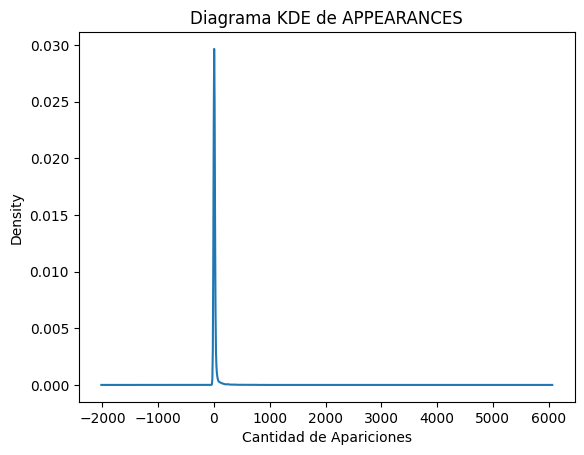

In [7]:
df_final['APPEARANCES'].plot(kind='kde')

plt.title('Diagrama KDE de APPEARANCES')
plt.xlabel('Cantidad de Apariciones')

plt.show()

## 2.3 Limpieza de Datos

Se debe aplicar los siguientes pasos de limpieza:

- **Eliminar duplicados** exactos del dataset.
- **Imputar valores nulos** en columnas categóricas con `'Desconocido'`.
- **Imputar valores nulos** en columnas numéricas con la **mediana** de la columna.


In [8]:
df_final = df_final.astype(str).drop_duplicates()

columnas_categoricas = df_final.select_dtypes(include='object').columns

for col in columnas_categoricas:
    df_final[col] = df_final[col].replace(['nan', '', ' '], pd.NA)
    df_final[col] = df_final[col].fillna('Desconocido')

for col in df_final.columns:
    try:
        df_final[col] = pd.to_numeric(df_final[col])
    except:
        pass

columnas_numericas = df_final.select_dtypes(include='number').columns

for col in columnas_numericas:
    mediana = df_final[col].median()
    df_final[col] = df_final[col].fillna(mediana)

display(df_final.isnull().sum())
display(df_final.shape)

C:\Users\User\AppData\Local\Temp\ipykernel_7260\3095428810.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df_final.select_dtypes(include='object').columns


status              0
code                0
message             0
total_records       0
data                0
origen              0
ID                  0
Name                0
URL                 0
Identity            0
Alignment           0
Eyes                0
Hair                0
Sex                 0
GSM                 0
Status              0
Appearances         0
First_Appearance    0
Year                0
page_id             0
name                0
urlslug             0
ALIGN               0
EYE                 0
HAIR                0
SEX                 0
ALIVE               0
APPEARANCES         0
FIRST APPEARANCE    0
FIRST_APPEARANCE    0
dtype: int64

(81880, 30)

Consulta y responde, para imputar valores nulos en columnas numericas, cuando es recomendable hacerlo con la media, la mediana, la moda o talvez existen alguna otra técnica?. Responde para cada caso cuando es recomendable

* **Media:** recomendable cuando los datos son equilibrados y no hay valores extremos.

* **Mediana:** recomendable cuando hay valores muy altos o muy bajos, porque no se ve tan afectada por ellos.

* **Moda:** recomendable cuando se quiere usar el valor que más se repite. Se usa mucho en datos categóricos.

* **Interpolación:** recomendable cuando los datos siguen un orden o una tendencia, como fechas o tiempo.

* **KNN o modelos predictivos:** recomendables cuando se quiere una estimación más precisa usando información de otros datos del dataset.

## 2.4 EDA PROFUNDO

Ejercicio 1. Comparación de personajes por década de creación  
Crea una columna de décadas a partir de YEAR.  
Cuenta cuántos personajes fueron creados en cada década.  
Identifica las décadas con mayor número de personajes.  
Realiza una breve interpretación de la evolución de creación de personajes a lo largo del tiempo.  

decada
1930.0      276
1940.0     5764
1950.0     1208
1960.0     5224
1970.0     8936
1980.0     9700
1990.0    14628
2000.0    12344
2010.0     4164
Name: count, dtype: int64

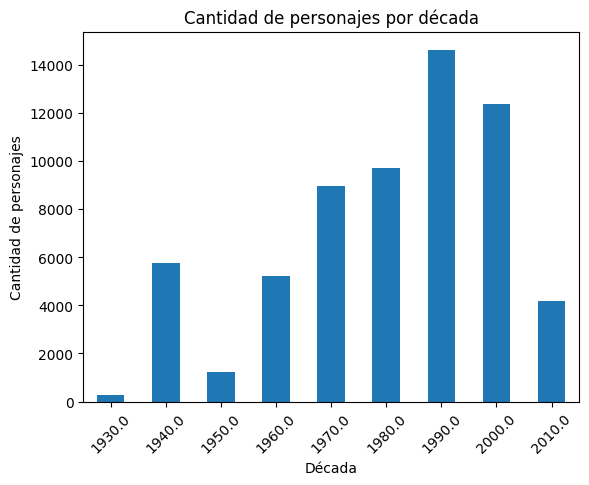

In [11]:
df_final['Year'] = pd.to_numeric(df_final['Year'], errors='coerce')

df_final['decada'] = (df_final['Year'] // 10) * 10

personajes_por_decada = df_final['decada'].value_counts().sort_index()

display(personajes_por_decada)

personajes_por_decada.plot(kind='bar')

plt.title('Cantidad de personajes por década')
plt.xlabel('Década')
plt.ylabel('Cantidad de personajes')

plt.xticks(rotation=45)

plt.show()

## 2.5 Preguntas

Responde las siguientes preguntas utilizando el dataset limpio:

1. ¿Cuántos personajes están vivos y cuántos han fallecido?
2. ¿Cuál es el color de cabello más común entre los personajes buenos?
3. ¿Qué porcentaje de personajes tiene identidad secreta?
4. ¿Cuál fue el año en que se crearon más personajes?


In [12]:
#1 
df_final['ALIVE'].value_counts()

ALIVE
Living Characters      37824
Desconocido            32758
Deceased Characters    11295
NULL                       3
Name: count, dtype: int64

In [13]:
#2 
df_buenos = df_final[df_final['ALIGN'] == 'Good Characters']

df_buenos['HAIR'].value_counts().head(1)

HAIR
Black Hair    3438
Name: count, dtype: int64

In [15]:
#3
total_personajes = df_final.shape[0]

identidad_secreta = df_final[df_final['ID'] == 'Secret Identity'].shape[0]

porcentaje = (identidad_secreta / total_personajes) * 100

print(f'Porcentaje: {porcentaje:.2f}%')

Porcentaje: 22.99%


In [18]:
#4
df_final['Year'] = pd.to_numeric(df_final['Year'], errors='coerce')

anio_max = df_final['Year'].value_counts().head(1)

display(anio_max)

Year
1993.0    2216
Name: count, dtype: int64

# Parte 3: Visualización de Datos(COMUNICACION DE INFORMACIÓN)


### EJERCICIO 1. Gráfico de tendencia: Evolución de la cantidad de personajes creados por año

- Analiza la cantidad de personajes creados cada año (YEAR).
- Crea un gráfico de línea que muestre la evolución del número de personajes creados a lo largo del tiempo.
- Realiza una interpretación del gráfico


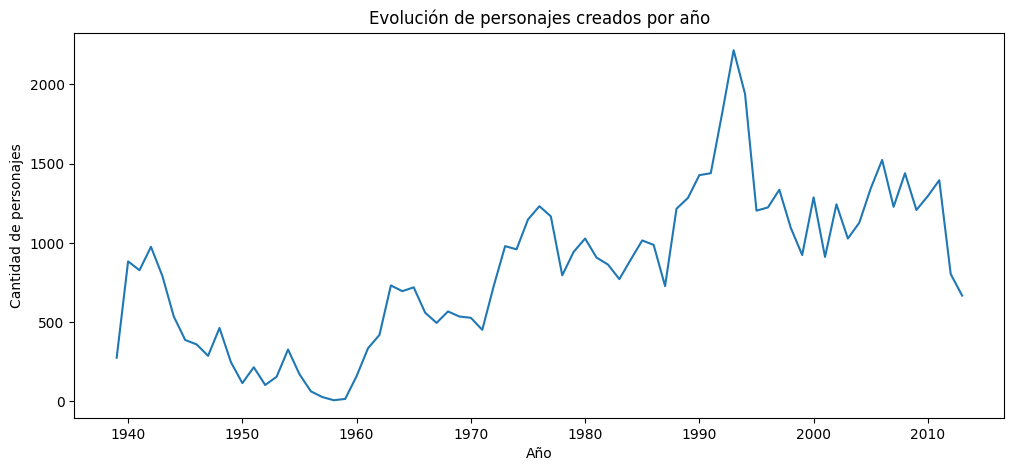

In [20]:
df_final['Year'] = pd.to_numeric(df_final['Year'], errors='coerce')

personajes_por_anio = df_final['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.plot(personajes_por_anio.index, personajes_por_anio.values)

plt.title('Evolución de personajes creados por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de personajes')

plt.show()

### EJERCICIO 2. Mapa de calor: Relación entre alineación y estado vivo/fallecido

- Analiza la relación entre la alineación del personaje (ALIGN) y su estado (ALIVE).
- Muestra un mapa de calor que cuente cuántos personajes de cada tipo (Bueno, Malo, Neutral) están vivos o fallecidos.
- Saca una conclusión del gráfico.


ALIVE,Deceased Characters,Desconocido,Living Characters,NULL
ALIGN,,,,
Bad Characters,5787,0,14373,0
Desconocido,932,32758,4686,0
Good Characters,2529,0,11379,0
NULL,466,0,2343,3
Neutral Characters,1581,0,5043,0


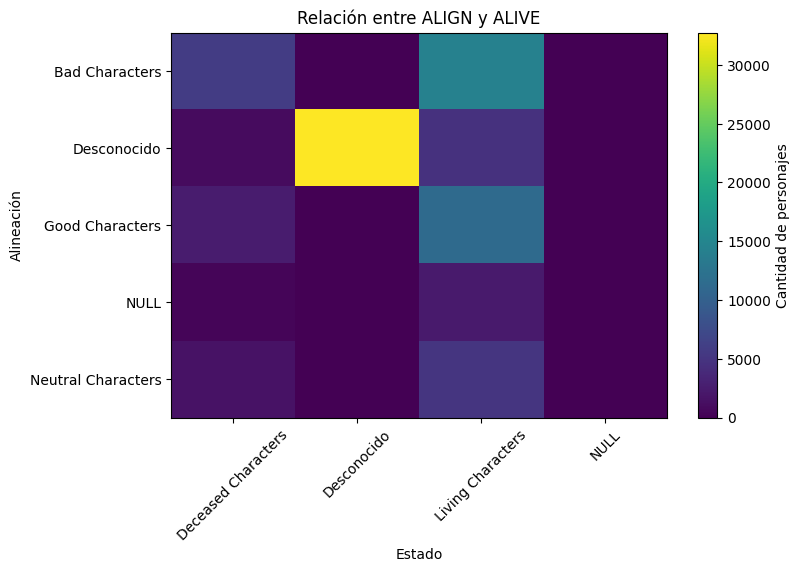

In [21]:
tabla = pd.crosstab(df_final['ALIGN'], df_final['ALIVE'])

display(tabla)

plt.figure(figsize=(8,5))

plt.imshow(tabla, aspect='auto')

plt.colorbar(label='Cantidad de personajes')

plt.xticks(range(len(tabla.columns)), tabla.columns, rotation=45)
plt.yticks(range(len(tabla.index)), tabla.index)

plt.title('Relación entre ALIGN y ALIVE')

plt.xlabel('Estado')
plt.ylabel('Alineación')

plt.show()

### EJERCICIO 3. Histograma: Distribución del número de creación de personajes por décadas

- Analiza cómo se distribuyen la creación de los personas por décadas (Year).
- Crea un histograma cuantos personajes se crearon para cada década.


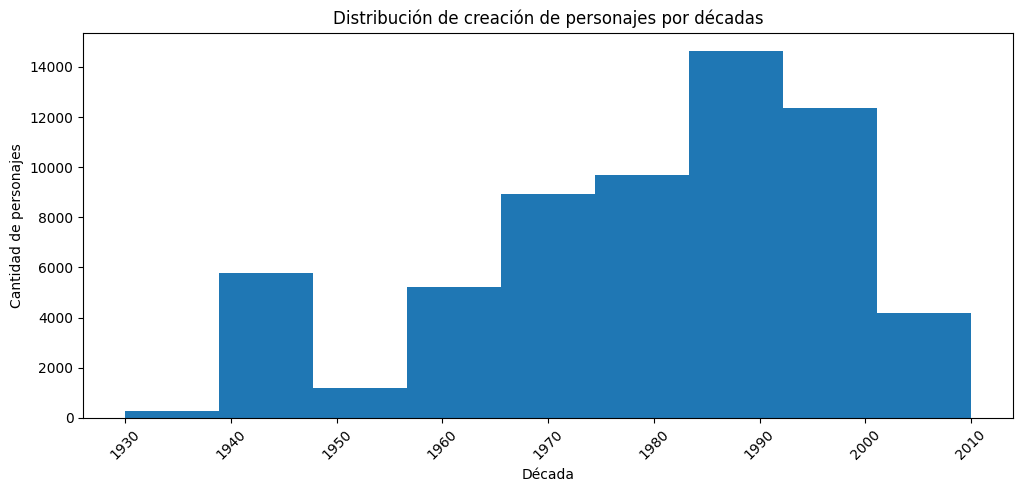

In [22]:
df_final['Year'] = pd.to_numeric(df_final['Year'], errors='coerce')

df_final['decada'] = (df_final['Year'] // 10) * 10

plt.figure(figsize=(12,5))

plt.hist(df_final['decada'].dropna(), bins=df_final['decada'].nunique())

plt.title('Distribución de creación de personajes por décadas')
plt.xlabel('Década')
plt.ylabel('Cantidad de personajes')

plt.xticks(rotation=45)

plt.show()

### EJERCICIO 4. Crea 4 diagramas adicionales, diferentes a los ya usados en este deber e interpreta los resultados, cada uno deberia mostrar información relevante que considera el estudiante mostrar.

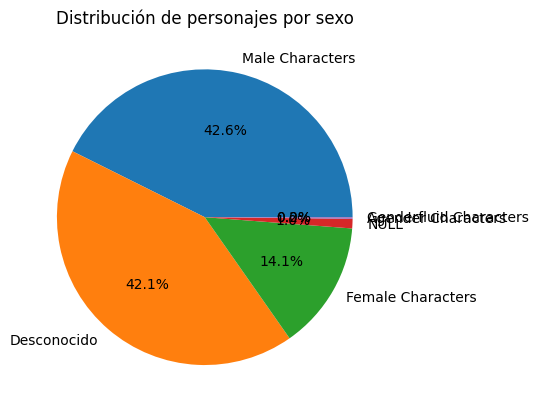

In [23]:
# Gráfico circular: Distribución de personajes por sexo
df_final['SEX'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Distribución de personajes por sexo')
plt.ylabel('')

plt.show()

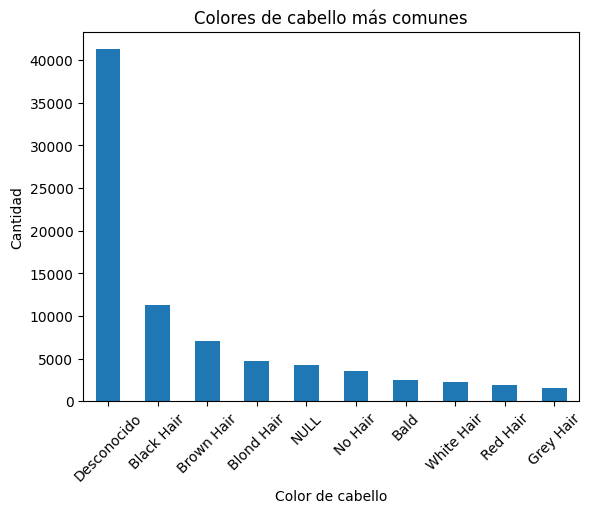

In [25]:
# Gráfico de barras: Colores de cabello más comunes
df_final['HAIR'].value_counts().head(10).plot(kind='bar')

plt.title('Colores de cabello más comunes')
plt.xlabel('Color de cabello')
plt.ylabel('Cantidad')

plt.xticks(rotation=45)

plt.show()

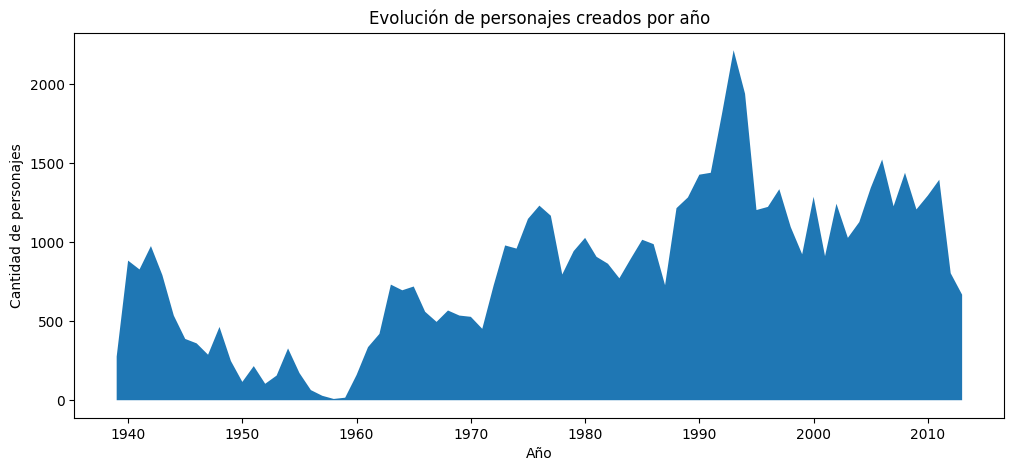

In [33]:
# Gráfico de área: Evolución de personajes creados por año
personajes_por_anio = df_final['Year'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.fill_between(
    personajes_por_anio.index,
    personajes_por_anio.values
)

plt.title('Evolución de personajes creados por año')
plt.xlabel('Año')
plt.ylabel('Cantidad de personajes')

plt.show()

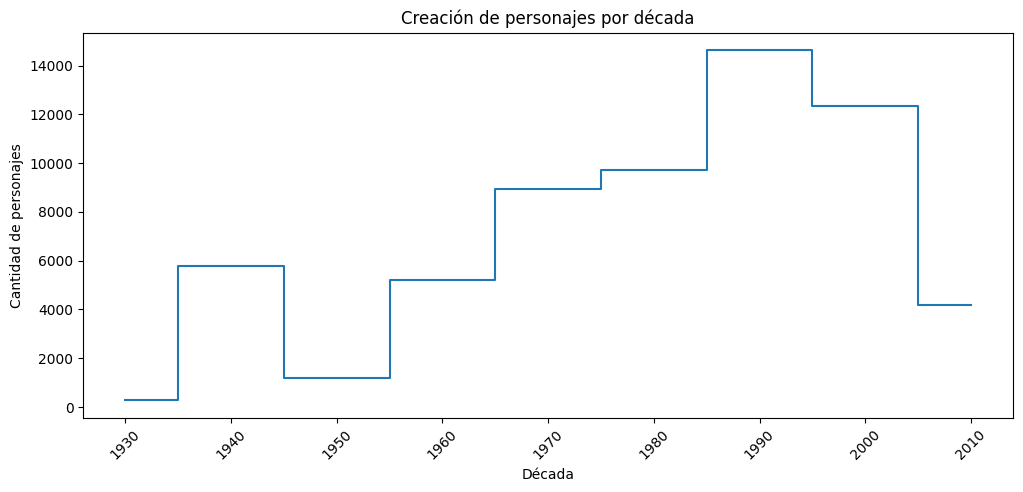

In [35]:
# Gráfico escalonado: Creación de personajes por década
personajes_por_decada = df_final['decada'].value_counts().sort_index()

plt.figure(figsize=(12,5))

plt.step(
    personajes_por_decada.index,
    personajes_por_decada.values,
    where='mid'
)

plt.title('Creación de personajes por década')
plt.xlabel('Década')
plt.ylabel('Cantidad de personajes')

plt.xticks(rotation=45)

plt.show()